# Exercise 1 — Predict Whether a Student Will Pass

## Goal

Build a **binary classification neural network** that predicts whether a student will pass based on:

- `hours_studied`
- `attendance`
- `previous_score`

Target:

- `0` = Fail
- `1` = Pass

### Neural network

```text
hours_studied ───┐
attendance ──────┼──> Dense → ReLU → Dense → Sigmoid → Pass/Fail
previous_score ──┘
```

## Concepts practiced

- neurons
- weights
- biases
- forward propagation
- ReLU
- sigmoid
- binary cross-entropy
- gradient descent
- backpropagation
- epochs
- batches

> **Important:** We will first understand the problem and data, then build the neural network using Keras/TensorFlow.


## 1. The problem

Imagine a school wants to identify students who may be at risk of failing.

For each student, we know:

| Feature | Meaning |
|---|---|
| `hours_studied` | Average study hours per day |
| `attendance` | Attendance percentage |
| `previous_score` | Previous exam/course score |

The model should learn:

```text
Student information
        ↓
Neural network
        ↓
Probability of passing
        ↓
Pass / Fail
```

### Question

Why is this a **classification** problem rather than a regression problem?


## 2. Load the dataset

The dataset is in:

`student_pass_dataset.csv`

### Your task

Load the CSV into a pandas DataFrame and display the first 10 rows.


In [1]:
# TODO: import pandas and load the dataset

import pandas as pd
df = pd.read_csv("student_pass_dataset - student_pass_dataset.csv")
df.head(10)


,student_id,hours_studied,attendance,previous_score,passed
0,1,0.9,81.0,64.6,0
1,2,5.7,83.9,83.4,1
2,3,4.5,100.0,51.5,1
3,4,4.8,100.0,71.3,0
4,5,3.4,59.3,57.2,0
5,6,10.6,87.5,68.6,1
6,7,4.4,87.2,45.1,0
7,8,4.1,82.9,73.7,0
8,9,5.7,91.1,68.1,0
9,10,5.0,81.4,84.6,0


## 3. Explore the data

Answer these questions:

1. How many students are in the dataset? : there are 600 students
2. What are the input features? :Hours_studied,Attendance and Previou_Score
3. What is the target? : Passed
4. Are there missing values? : There is no missing value in the dataset
5. How many students passed? : 200 students are passed 
6. How many students failed? : 400 students are passed

Try using:

```python
df.shape
df.info()
df.isnull().sum()
df["passed"].value_counts()
```


In [2]:
# TODO: explore the dataset
print(df.shape)
print("="*60)
print(df.info())
print("="*60)
print(df.isnull().sum())
print("="*60)
df["passed"].value_counts()


(600, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      600 non-null    int64  
 1   hours_studied   600 non-null    float64
 2   attendance      600 non-null    float64
 3   previous_score  600 non-null    float64
 4   passed          600 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 23.6 KB
None
student_id        0
hours_studied     0
attendance        0
previous_score    0
passed            0
dtype: int64


passed
0    400
1    200
Name: count, dtype: int64

## 4. Separate inputs and target

The neural network needs:

```text
X = input features
y = target
```

Use the three columns:

```text
hours_studied
attendance
previous_score
```

as `X`.

Use:

```text
passed
```

as `y`.

### Question

Why should `student_id` NOT be used as an input feature?

Becuase student id is act as an  iidentifier of each student than as a feature


In [3]:
# TODO: create X and y

X = df[["hours_studied", "attendance", "previous_score"]]
y = df["passed"]
print(X.head())
print("===========================================")
y.head()

   hours_studied  attendance  previous_score
0            0.9        81.0            64.6
1            5.7        83.9            83.4
2            4.5       100.0            51.5
3            4.8       100.0            71.3
4            3.4        59.3            57.2


0    0
1    1
2    1
3    0
4    0
Name: passed, dtype: int64

## 5. Train/test split

We need to evaluate the model on students it has not seen during training.

Use:

- 80% training data
- 20% testing data
- `random_state=42`
- `stratify=y`

Why is `stratify=y` useful for a classification problem?

stratify=y makes sure that the training and testing datasets have a similar distribution of the target classes (passed and failed).


In [4]:
# TODO: split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Train_Test splitted sucessfully")

Train_Test splitted sucessfully


## 6. Scale the features

Notice that our features have different ranges:

```text
hours_studied   → roughly 0–12
attendance      → roughly 35–100
previous_score  → roughly 20–100
```

Neural networks usually train more effectively when numerical inputs are on similar scales.

Use `StandardScaler`.

**Important:** fit the scaler only on the training data, then transform both training and test data.


In [5]:
# TODO: standardize X_train and X_test

from sklearn.preprocessing import StandardScaler


# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled sucessfully")

Scaled sucessfully


## 7. Build the neural network

Create this architecture:

```text
Input: 3 features
       ↓
Dense(8)
       ↓
ReLU
       ↓
Dense(4)
       ↓
ReLU
       ↓
Dense(1)
       ↓
Sigmoid
       ↓
Probability of passing
```

### Think about the layers

- Why are there 3 input values? : Because we have 3 features:study-hour,previous-score and attendace
- Why do we use ReLU in the hidden layers? : It helps the neural network learn complex and non-linear patterns.
- Why does the final layer have only 1 neuron? : Because this is a binary classification problem.
- Why do we use sigmoid at the output? : The sigmoid function converts the output into a value between 0 and 1: 0≤Probability≤1


In [7]:
# TODO: import TensorFlow/Keras and build the model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(8, activation="relu", input_shape=(3,)),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])



C:\Users\biniyam\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 8. Compile the model

Use:

- optimizer: `adam`
- loss: `binary_crossentropy`
- metric: `accuracy`

### Important concept

During training:

```text
prediction
    ↓
binary cross-entropy
    ↓
loss
    ↓
backpropagation
    ↓
gradients
    ↓
update weights
```

The optimizer uses the gradients to update the network's weights.


In [8]:
# TODO: compile the model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 9. Train the model

Train for around **50 epochs** with:

- batch size = 16
- validation split = 20%

Watch the training and validation loss.

### Questions

1. Does the loss generally decrease? : Yes, normally.
2. What does one epoch mean? : An epoch means the model has gone through the entire training dataset once.
3. What does the batch size control? : Batch size controls the number of training samples processed before the model updates its weights.
4. Why might training accuracy continue increasing while validation accuracy stops improving? : This can be a sign of overfitting.


In [9]:
# TODO: train the model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

for epoch, (loss, val_loss) in enumerate(
    zip(history.history["loss"], history.history["val_loss"]), start=1
):
    print(f"Epoch {epoch}: Loss={loss:.4f}, Val Loss={val_loss:.4f}")


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6484 - loss: 0.6929 - val_accuracy: 0.6146 - val_loss: 0.7160
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6797 - loss: 0.6754 - val_accuracy: 0.6146 - val_loss: 0.7016
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6797 - loss: 0.6608 - val_accuracy: 0.6146 - val_loss: 0.6876
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6797 - loss: 0.6452 - val_accuracy: 0.6146 - val_loss: 0.6744
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6797 - loss: 0.6278 - val_accuracy: 0.6146 - val_loss: 0.6613
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6797 - loss: 0.6093 - val_accuracy: 0.6146 - val_loss: 0.6479
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6797 - loss: 0.5917 - val_accuracy: 0.6146 - val_loss: 0.6348
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6797 - loss: 0.5767 - val_accuracy: 0.6146 - val_loss

## 10. Plot the learning curves

Plot:

1. training loss vs validation loss
2. training accuracy vs validation accuracy

Look for evidence of:

- learning
- underfitting
- overfitting


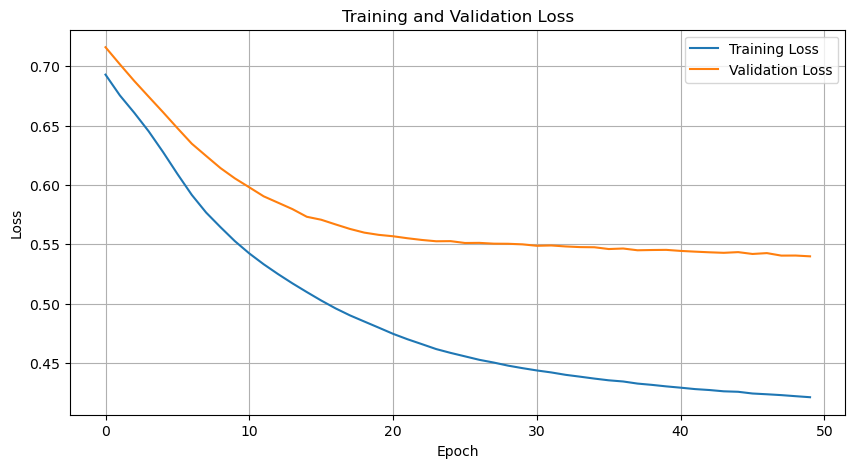

In [10]:
# TODO: plot training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


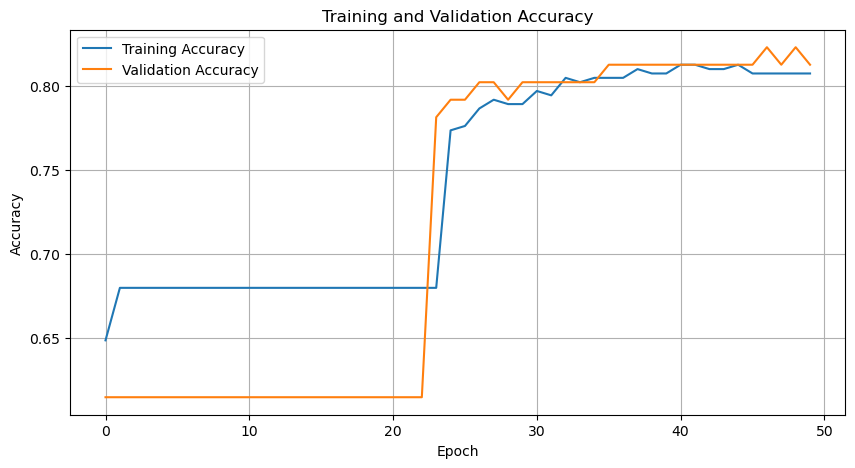

In [11]:
# TODO: plot training and validation accuracy

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 11. Evaluate on the test set

Calculate:

- test loss
- test accuracy

Remember:

> The test set should represent data the model did not use to learn its weights.


In [12]:
# TODO: evaluate the model on the test set

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8000 - loss: 0.4630 
Test Loss: 0.4629909098148346
Test Accuracy: 0.800000011920929


## 12. Make predictions

The sigmoid output is a probability between 0 and 1.

For example:

```text
0.92 → likely pass
0.18 → likely fail
```

Use a threshold of `0.5`:

```python
prediction >= 0.5 → 1
prediction < 0.5  → 0
```

Make predictions for the test set.


In [13]:
# TODO: generate probabilities and convert them to 0/1 predictions
# Generate prediction probabilities
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities to 0/1 predictions using 0.5 threshold
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Probabilities:")
print(y_pred_prob[:10])

print("\nPredictions:")
print(y_pred[:10])


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 
Probabilities:
[[0.07177276]
 [0.56720716]
 [0.56720716]
 [0.31416038]
 [0.56720716]
 [0.56720716]
 [0.46196496]
 [0.37984022]
 [0.34606934]
 [0.11178137]]

Predictions:
[[0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]]


## 13. Confusion matrix

Create a confusion matrix.

Interpret:

- True Positive
- True Negative
- False Positive
- False Negative

### Question

Which mistake would you consider more serious in a school intervention system?

**False positive:** the model says a student will pass, but they fail.

**False negative:** the model says a student will fail, but they pass.

Explain your reasoning.


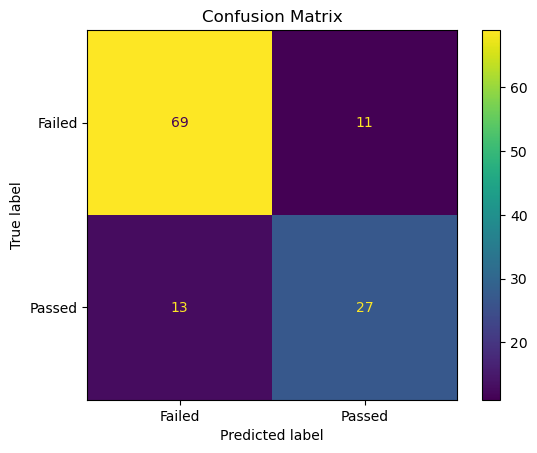

In [14]:
# TODO: create and display a confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Failed", "Passed"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


## 14. Try your own students

Create 5 hypothetical students.

Example:

```text
hours_studied = 8
attendance = 92
previous_score = 78
```

Ask the neural network to predict their probability of passing.

Try some borderline cases too.

### Challenge

Can you find a student for whom the model is uncertain, such as a prediction around:

```text
0.45–0.55
```

Why might the model be uncertain?


In [17]:
import pandas as pd

# Create 5 hypothetical students
new_students = pd.DataFrame({
    "hours_studied": [8, 2, 6, 5, 4],
    "attendance": [92, 50, 75, 70, 65],
    "previous_score": [78, 35, 60, 55, 50]
})

# Display students
print(new_students)
print("==============================================================")

# scale this data
new_students_scaled = scaler.transform(new_students)

# Predict the probability of passing
predictions = model.predict(new_students_scaled)

# Add probabilities to the DataFrame
new_students["pass_probability"] = predictions

# Convert probability to prediction using threshold 0.5
new_students["prediction"] = (
    new_students["pass_probability"] >= 0.5
).astype(int)

print(new_students)

   hours_studied  attendance  previous_score
0              8          92              78
1              2          50              35
2              6          75              60
3              5          70              55
4              4          65              50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
   hours_studied  attendance  previous_score  pass_probability  prediction
0              8          92              78          0.567207           1
1              2          50              35          0.000420           0
2              6          75              60          0.325694           0
3              5          70              55          0.073489           0
4              4          65              50          0.016243           0


# Reflection

Answer these questions in your own words:

1. What is a neuron doing? : A neuron receives input values, performs a mathematical calculation using weights and bias, applies an activation function, and produces an output.
2. What is the purpose of a weight? : A weight represents the importance of an input.
3. What is a bias? : A bias is an additional value added to a neuron's calculation that used to adjust the output and make patterns more flexible
4. What happens during forward propagation? : During forward propagation, data moves from the input layer through the hidden layers to the output layer.
5. Why do we need an activation function? : Activation functions allow neural networks to learn complex and non-linear patterns.
6. Why is sigmoid useful for binary classification? : Sigmoid converts the network output into a value between 0 and 1.
7. What does binary cross-entropy measure? : Binary cross-entropy measures how different the model's predicted probability is from the actual binary value (0 or 1).
8. What happens during backpropagation? : During backpropagation, the neural network works backward from the output layer.

It calculates how much each weight and bias contributed to the prediction error.
9. What does gradient descent change? : Gradient descent changes the weights and biases to reduce the loss.
10. What is an epoch? : An epoch is one complete pass through the entire training dataset.
11. What is a batch? : A batch is a small group of training examples processed together before the model updates its weights.
12. Why do we keep a separate test set? :We keep a separate test set to evaluate how well the model performs on new, unseen data.

## Final challenge

Change the architecture and compare:

```text
Model A:
3 → 4 → 1

Model B:
3 → 8 → 4 → 1

Model C:
3 → 32 → 16 → 8 → 1
```

Compare their validation and test performance.

**Question:** Does a bigger network always perform better?
